# Radial Shell Integrals

This notebook demonstrates the simplest use of `integrate_box(...)` for spherical trees: integrate one scalar field over many full-angular radial shells.

The shells are specified only by their radial edges. For each interval `[r0, r1]`, the integral covers the full angular domain
`0 <= polar <= pi`, `0 <= azimuth <= 2 pi`.


The setup cell below loads the bundled BATSRUS sample, builds an `rpa` octree, and attaches an interpolator for `Rho [g/cm^3]`.

In [15]:
from batread import Dataset
import matplotlib.pyplot as plt
import numpy as np

from batcamp import Octree, OctreeInterpolator

ds = Dataset.from_file("../sample_data/3d__var_1_n00000000.plt")
tree = Octree.from_ds(ds, tree_coord="rpa")
interp = OctreeInterpolator(tree, ds["Rho [g/cm^3]"])


The code here builds integrates over $r$ from 1 to various radii and plots the result.

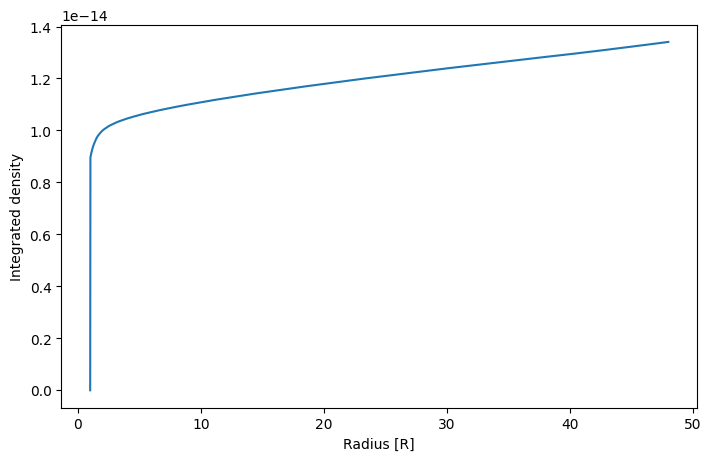

In [5]:
radii = np.geomspace(1, 48, 200)
integrals = [interp.integrate_box(
    [0, 0, 0],
    [r, np.pi, 2 * np.pi]
)
    for r in radii
]

fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
ax.plot(radii, integrals)
ax.set_xlabel("Radius [R]")
ax.set_ylabel("Integrated density")
plt.show()
